In [19]:
import pandas as pd

# Read Excel file
df = pd.read_excel(
    r"C:\& Satheesh\Outbound-Calling-Conversion-Model\data\Customer_Segmentation_Next_Best_Action.xlsx"
)

# Display first 5 rows
df.head()

C:\Users\sgsam\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:81: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
C:\Users\sgsam\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:81: UserWarning: Conditional Formatting extension is not supported and will be removed
  for idx, row in parser.parse():


,customer_id,customer_name,product_type,fresco_segment,age_band,region,days_to_maturity,active_dd,failed_dd,account_value,online_login_days,complaints,previous_campaign_response,email_open_rate,web_visits_30d,has_adviser,segment_weight,conversion_score,priority,next_best_action
0,200001,Mia Wilson,ISA,Retired Security Seekers,18-24,South West,53,No,No,3348,152,0,Yes,0.19,8,No,10,65,High,Outbound call
1,200002,Mia Thompson,ISA,Cautious Savers,65+,East of England,143,No,Yes,26905,41,1,No,0.13,12,No,8,46,Medium,Digital nurture
2,200003,Grace Evans,CTF,Digital Natives,18-24,South East,236,Yes,No,12903,21,1,No,0.53,5,No,13,83,High,Outbound call
3,200004,Sophia Jones,ISA,Budget Conscious,18-24,North West,52,Yes,No,27832,94,0,No,0.57,11,No,5,95,Very High,Priority outbound call
4,200005,Evie Wilson,ISA,Rising Professionals,55-64,South West,237,Yes,No,21471,177,1,No,0.72,12,Yes,14,74,High,Outbound call


In [57]:
print(df.columns)

Index(['customer_id', 'customer_name', 'product_type', 'fresco_segment',
       'age_band', 'region', 'days_to_maturity', 'active_dd', 'failed_dd',
       'account_value', 'online_login_days', 'complaints',
       'previous_campaign_response', 'email_open_rate', 'web_visits_30d',
       'has_adviser', 'segment_weight', 'conversion_score', 'priority',
       'next_best_action'],
      dtype='object')


In [43]:

# ---------------------------------------------------------
# Customer Segmentation & Next Best Action Model
# Includes Fresco-style segmentation scoring
# ---------------------------------------------------------


def calculate_conversion_score(row):
    score = 0

    # 1. Fresco segment scoring
    if row["fresco_segment"] == "Affluent Families":
        score += 25
    elif row["fresco_segment"] == "Mature Wealth":
        score += 20
    elif row["fresco_segment"] == "Retired Comfort":
        score += 18
    elif row["fresco_segment"] == "Digital Achievers":
        score += 15
    elif row["fresco_segment"] == "Budget Households":
        score += 5

    # 2. Maturity date scoring
    if row["days_to_maturity"] <= 30:
        score += 30
    elif row["days_to_maturity"] <= 90:
        score += 20
    elif row["days_to_maturity"] <= 180:
        score += 10

    # 3. Account value scoring
    if row["account_value"] >= 15000:
        score += 30
    elif row["account_value"] >= 10000:
        score += 25
    elif row["account_value"] >= 5000:
        score += 15

    # 4. Direct Debit scoring
    if row["active_dd"] == "Yes":
        score += 20

    if row["failed_dd"] == "Yes":
        score -= 15

    # 5. Online engagement
    if row["online_login_days"] <= 30:
        score += 15
    elif row["online_login_days"] <= 90:
        score += 10

    # 6. Complaints
    if row["complaints"] == 0:
        score += 10
    elif row["complaints"] >= 2:
        score -= 20

    # 7. Previous campaign response
    if row["previous_campaign_response"] == "Yes":
        score += 20

    # 8. Email engagement
    if row["email_open_rate"] >= 60:
        score += 15
    elif row["email_open_rate"] >= 30:
        score += 10

    # 9. Web engagement
    if row["web_visits_30d"] >= 5:
        score += 15
    elif row["web_visits_30d"] >= 2:
        score += 10

    # 10. Adviser relationship
    if row["has_adviser"] == "Yes":
        score += 10

    return score


def assign_priority(score):
    if score >= 90:
        return "Very High Priority"
    elif score >= 70:
        return "High Priority"
    elif score >= 40:
        return "Medium Priority"
    else:
        return "Low Priority"


def recommend_next_best_action(row):
    if row["priority"] in ["Very High Priority", "High Priority"]:

        if row["product_type"] == "ISA":
            return "ISA reinvestment call"

        elif row["product_type"] == "JISA":
            return "JISA maturity follow-up"

        elif row["product_type"] == "CTF":
            return "CTF to ISA conversion call"

        elif row["product_type"] == "Over 50":
            return "Over 50 retention call"

    elif row["priority"] == "Medium Priority":
        return "Send targeted email campaign"

    else:
        return "Low priority nurture campaign"


# ---------------------------------------------------------
# Main process
# ---------------------------------------------------------

input_path = r"C:\& Satheesh\Customer Segmentation & Next Best Action\data\Customer_Segmentation_Next_Best_Action.xlsx"

output_path = r"C:\& Satheesh\Customer Segmentation & Next Best Action\output\customer_segmentation_output.xlsx"


# Read Excel file
df = pd.read_excel(input_path)

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Apply scoring model
df["conversion_score"] = df.apply(calculate_conversion_score, axis=1)

# Assign priority
df["priority"] = df["conversion_score"].apply(assign_priority)

# Recommend next best action
df["next_best_action"] = df.apply(recommend_next_best_action, axis=1)

# Sort highest priority customers first
df = df.sort_values(by="conversion_score", ascending=False)

# Export output file
df.to_excel(output_path, index=False)

print("Customer segmentation model completed successfully.")
print(f"Output file created: {output_path}")

print("\nTop 10 customers:")
print(
    df[
        [
            "customer_id",
            "customer_name",
            "product_type",
            "fresco_segment",
            "conversion_score",
            "priority",
            "next_best_action",
        ]
    ].head(10)
)

C:\Users\sgsam\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:81: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
C:\Users\sgsam\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:81: UserWarning: Conditional Formatting extension is not supported and will be removed
  for idx, row in parser.parse():


Customer segmentation model completed successfully.
Output file created: C:\& Satheesh\Customer Segmentation & Next Best Action\output\customer_segmentation_output.xlsx

Top 10 customers:
    customer_id  customer_name product_type            fresco_segment  \
33       200034    Harry Jones          ISA  Retired Security Seekers   
52       200053    Oscar White          ISA           Cautious Savers   
26       200027   Thomas Evans          CTF      Rising Professionals   
63       200064    Aarav Patel          ISA  Retired Security Seekers   
55       200056  Evie Thompson      Over 50        Affluent Achievers   
12       200013      Mia Jones          CTF        Affluent Achievers   
30       200031     Mia Davies          CTF  Retired Security Seekers   
22       200023   Amelia Jones          ISA        Affluent Achievers   
83       200084     Isla Patel          ISA      Rising Professionals   
7        200008    Jack Walker          ISA      Comfortable Families   

    conv

In [41]:
df.head(10)

,customer_id,customer_name,product_type,fresco_segment,age_band,region,days_to_maturity,active_dd,failed_dd,account_value,online_login_days,complaints,previous_campaign_response,email_open_rate,web_visits_30d,has_adviser,segment_weight,conversion_score,priority,next_best_action
0,200001,Mia Wilson,ISA,Retired Security Seekers,18-24,South West,53,No,No,3348,152,0,Yes,0.19,8,No,10,40,Medium Priority,ISA Retention Call
1,200002,Mia Thompson,ISA,Cautious Savers,65+,East of England,143,No,Yes,26905,41,1,No,0.13,12,No,8,10,Low Priority,ISA Retention Call
2,200003,Grace Evans,CTF,Digital Natives,18-24,South East,236,Yes,No,12903,21,1,No,0.53,5,No,13,50,Medium Priority,CTF Conversion Campaign
3,200004,Sophia Jones,ISA,Budget Conscious,18-24,North West,52,Yes,No,27832,94,0,No,0.57,11,No,5,65,Medium Priority,ISA Retention Call
4,200005,Evie Wilson,ISA,Rising Professionals,55-64,South West,237,Yes,No,21471,177,1,No,0.72,12,Yes,14,45,Medium Priority,ISA Retention Call
5,200006,Oscar Jones,Over 50,Cautious Savers,65+,North West,291,No,No,21977,128,0,No,0.39,4,Yes,8,25,Low Priority,Over 50 Renewal Call
6,200007,Thomas Wright,ISA,Retired Security Seekers,55-64,East of England,205,Yes,No,5032,131,0,No,0.73,2,No,10,20,Low Priority,ISA Retention Call
7,200008,Jack Walker,ISA,Comfortable Families,45-54,East of England,240,Yes,No,28706,3,1,Yes,0.75,12,No,12,80,High Priority,ISA Retention Call
8,200009,Freya Brown,ISA,Retired Security Seekers,18-24,Wales,2,No,No,9130,129,1,No,0.09,10,No,10,30,Low Priority,ISA Retention Call
9,200010,Muhammad Roberts,ISA,Budget Conscious,55-64,South West,277,No,No,518,154,0,Yes,0.79,12,No,5,20,Low Priority,ISA Retention Call


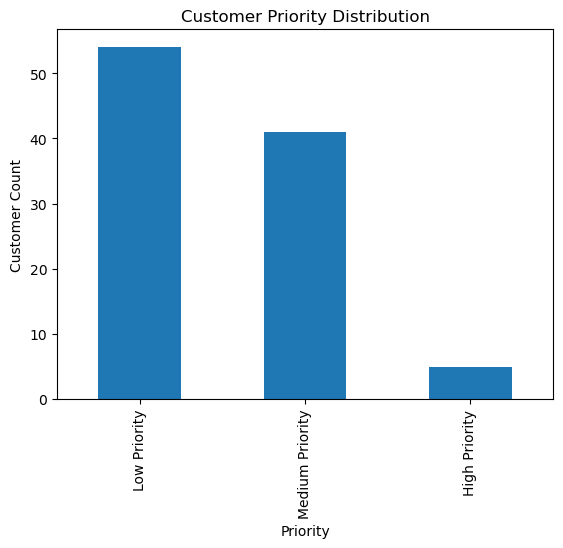

In [51]:
import matplotlib.pyplot as plt

df["priority"].value_counts().plot(kind="bar")

plt.title("Customer Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Customer Count")

plt.show()

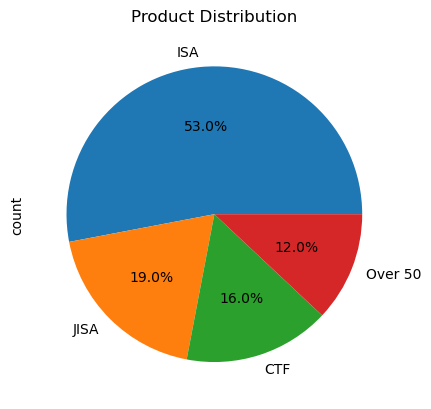

In [53]:
df["product_type"].value_counts().plot(kind="pie", autopct='%1.1f%%')

plt.title("Product Distribution")

plt.show()

In [55]:
top_customers = df.sort_values(
    by="conversion_score",
    ascending=False
).head(10)

print(top_customers[
    [
        "customer_name",
        "product_type",
        "conversion_score",
        "priority",
        "next_best_action"
    ]
])

     customer_name product_type  conversion_score         priority  \
52     Oscar White          ISA                85    High Priority   
33     Harry Jones          ISA                80    High Priority   
7      Jack Walker          ISA                80    High Priority   
55   Evie Thompson      Over 50                75    High Priority   
30      Mia Davies          CTF                75    High Priority   
12       Mia Jones          CTF                65  Medium Priority   
22    Amelia Jones          ISA                65  Medium Priority   
83      Isla Patel          ISA                65  Medium Priority   
89  Thomas Johnson          ISA                65  Medium Priority   
20     Evie Thomas          ISA                65  Medium Priority   

              next_best_action  
52       ISA reinvestment call  
33       ISA reinvestment call  
7        ISA reinvestment call  
55      Over 50 retention call  
30  CTF to ISA conversion call  
12  CTF to ISA conversion call 